In [1]:
from TiedMallowsObject import *
import numpy as np
import random
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

## Find MAP

## Generate data


In [2]:
def generate_mixture_data(
    n_assessors=100,
    n_items=10,
    C=3,
    seed=1,
    gap=1.2,
    sigma=0.8,
    tau=None,
    n_blocks=None,
    n_blocks_range=(3, 6),
    min_block_size=1,
):
    rng = np.random.default_rng(seed)

    if n_items < 1:
        raise ValueError("n_items must be >= 1")
    if C < 1:
        raise ValueError("C must be >= 1")
    if min_block_size < 1:
        raise ValueError("min_block_size must be >= 1")

    # ---- tau ----
    if tau is None:
        tau = np.ones(C) / C
    else:
        tau = np.asarray(tau, dtype=float)
        if tau.shape != (C,):
            raise ValueError(f"tau must have length C={C}")
        if tau.sum() <= 0:
            raise ValueError("tau must sum to a positive value")
        tau = tau / tau.sum()

    def choose_k():
        if n_blocks is not None:
            k = int(n_blocks)
        else:
            lo, hi = n_blocks_range
            if lo < 1 or hi < lo:
                raise ValueError("n_blocks_range must be (low>=1, high>=low)")
            k = int(rng.integers(lo, hi + 1))

        # cap so we can give each block at least min_block_size items
        k_max = n_items // min_block_size
        if k_max < 1:
            # min_block_size > n_items, so only possible is 1 block
            return 1
        return max(1, min(k, k_max))

    def sizes_no_empty(total, k, min_part):
        """
        Return k sizes summing to total, each >= min_part.
        This cannot produce zeros.
        """
        base = np.full(k, min_part, dtype=int)
        remaining = total - k * min_part
        if remaining < 0:
            raise ValueError(f"Impossible: total={total}, k={k}, min_part={min_part}")

        # distribute remaining across k blocks (some blocks may get +0, but base ensures >= min_part)
        extras = rng.multinomial(remaining, np.ones(k) / k)
        sizes = base + extras

        # Optional: randomize the order of sizes so earlier blocks aren't biased
        rng.shuffle(sizes)
        return sizes.tolist()

    def make_cluster_blocks():
        k = choose_k()
        sizes = sizes_no_empty(n_items, k, min_block_size)

        items = rng.permutation(n_items).tolist()
        blocks = []
        idx = 0
        for sz in sizes:
            block = items[idx: idx + sz]
            # This should *never* happen now, but keep as a hard check
            if len(block) == 0:
                raise RuntimeError("Empty block generated — this should be impossible.")
            blocks.append(block)
            idx += sz

        # sanity checks
        if idx != n_items:
            raise RuntimeError("Internal error: did not consume exactly n_items.")
        if len(set(x for b in blocks for x in b)) != n_items:
            raise RuntimeError("Internal error: items repeated or missing.")
        return blocks

    true_blocks = [make_cluster_blocks() for _ in range(C)]

    z_true = rng.choice(C, size=n_assessors, p=tau)

    def ranking_from_blocks(blocks):
        base = np.zeros(n_items)
        for level, block in enumerate(blocks):
            for item in block:
                base[item] = -gap * level
        scores = base + rng.normal(0.0, sigma, size=n_items)
        return list(np.argsort(-scores))

    rankings = [ranking_from_blocks(true_blocks[z]) for z in z_true]

    return true_blocks, tau.tolist(), z_true.tolist(), rankings

# Map prediciton to true labels

In [3]:
def match_clusters(z_true, z_pred):
    z_true = np.asarray(z_true)
    z_pred = np.asarray(z_pred)

    true_labels = np.unique(z_true)
    pred_labels = np.unique(z_pred)

    # map original labels to 0..T-1 and 0..P-1
    t2i = {t:i for i,t in enumerate(true_labels)}
    p2j = {p:j for j,p in enumerate(pred_labels)}
    T, P = len(true_labels), len(pred_labels)

    # contingency / confusion counts
    M = np.zeros((T, P), dtype=int)
    for t, p in zip(z_true, z_pred):
        M[t2i[t], p2j[p]] += 1

    # maximize matches -> minimize negative matches
    row_ind, col_ind = linear_sum_assignment(-M)

    # build mapping from predicted label -> matched true label
    pred_to_true = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    # relabel predictions (unmatched preds, if any, stay as-is or set to -1)
    z_pred_aligned = np.array([pred_to_true.get(p, -1) for p in z_pred])

    accuracy = (z_pred_aligned == z_true).mean()

    return pred_to_true, M, z_pred_aligned, accuracy

## Run MCMC

In [4]:
import math
from itertools import permutations
from TiedMallowsObject import *
from sklearn.metrics import adjusted_rand_score

# ============================================================
# ---------------- Example usage -----------------------------
# ============================================================

if __name__ == "__main__":
    # Generate data
    C_true = 3
    C = 6
    n_items = 10
    n_blocks_range=(5, 8)

    true_blocks, true_tau, z_true, rankings = generate_mixture_data(
    n_assessors=100,
    seed=42,
    gap=1.2,
    sigma=1,
    C = C_true,
    n_items=n_items,
    n_blocks_range=n_blocks_range
    )

    # ---- MCMC settings ----
    init_mu = [1/(C) for _ in range(C)]   # Use small priors with overfitted model to obtain optimal clustering

    model = MixtureRankingModel(rankings,
                                n_clusters=C,
                                 init_mu=init_mu, 
                                 seed=123,
                                 verbose=True)

    # when calling run_mcmc you can override PY parameters via sampler kwargs
    # here we also activate the new PY-prior MH move with p_py>0
    final_state, samples = model.run_mcmc(
        n_iter=20000,
        burn_in=5000,
        thin=5,
        save_samples=True,
        save_tau=True,
        save_theta=True,
        n_item_moves_per_cluster=2,
        p_gibbs = 0,
        p_transfer=0.4,
        p_swapshift=0.4,
        p_splitmerge=0.2,
        p_py=0,                     # use PY-prior MH reassignment moves
        gamma = 1,        # global gamma override (optional)
        delta = 0.2,        # global delta override (optional)
    )

    if samples is not None:
        summaries = model.estimate_map(samples, ci=0.95)
        print("MAP-like summaries:", summaries)

[Model] Initialized (100 assessors, 10 items, 6 clusters)
[Model] Numba JIT: enabled
  Cluster 0: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 10 blocks, theta=1.000, gamma=1.000, delta=0.500

[MCMC] Starting run: n_iter=20000, burn_in=5000, thin=5
[MCMC] Sampler config: p_gibbs=0.000, p_transfer=0.400, p_swapshift=0.400, p_splitmerge=0.200, p_py=0.000
[MCMC] Item moves per cluster: 2
[MCMC] Will save 3000 iterations after burn-in

[MCMC]   10.0% | iter   2001/20000 |    55.9s elapsed | ETA   8.4 min
[MCMC]   25.0% | iter   5001/20000 |   141.1s elapsed | ETA   7.1 min
[MCMC]   50.0% | iter  10001/20000 |   282.3s elapsed | ETA   4.7 min
[MCMC]   75.0% | iter  15001/20000 |   432.4s elapsed | ETA   2.4 min
[MCMC]   90.0% | it

In [6]:
z_map = summaries["labels"]["z_hat"]
pred_to_true, M, z_aligned, acc = match_clusters(z_true, z_map)
print("accuracy after relabel:", acc)
print("contingency:\n", M)

accuracy after relabel: 0.39
contingency:
 [[35]
 [39]
 [26]]


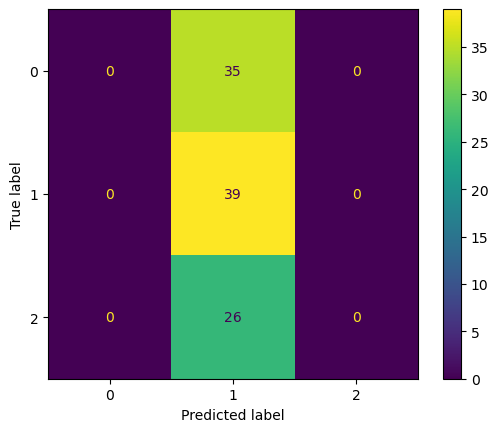

In [7]:
disp = ConfusionMatrixDisplay.from_predictions(z_true, z_aligned)

In [23]:
for cl in summaries["consensus_blocks"]:
    c = cl["cluster"]
    c_aligned = pred_to_true.get(c, None)
    blocks_hat = cl["blocks_hat"]      # e.g. [[0,2],[1],[3,4]]
    prob    = cl["posterior_prob"]     # fraction of saved iter’s matching
    print(f"original cluster {c} and aligned cluster {c_aligned} consensus:", blocks_hat, f"(freq {prob:.3f})")

original cluster 0 and aligned cluster None consensus: [[5], [2], [14], [6], [9], [3], [4], [11], [10], [8], [1], [7], [0], [12], [13]] (freq 1.000)
original cluster 1 and aligned cluster 0 consensus: [[4, 7, 14], [2, 5, 12], [1], [8, 9, 10, 11], [0, 3, 6, 13]] (freq 0.357)
original cluster 2 and aligned cluster 2 consensus: [[0, 2, 3, 11], [6], [5, 9], [8, 14], [4, 13], [10, 12], [1, 7]] (freq 0.197)
original cluster 3 and aligned cluster None consensus: [[5], [2], [14], [6], [9], [3], [4], [11], [10], [1], [8], [7, 12], [0], [13]] (freq 1.000)
original cluster 4 and aligned cluster None consensus: [[5], [2], [6], [14], [9], [3], [4], [10], [11], [8], [1], [7], [12], [0], [13]] (freq 1.000)
original cluster 5 and aligned cluster 1 consensus: [[6], [2, 3, 5, 9, 10], [1, 8, 14], [4, 11], [0, 7, 12, 13]] (freq 0.423)


In [24]:
# Build true → predicted mapping
true_to_pred = {t: p for p, t in pred_to_true.items()}

# Build quick lookup for predicted summaries by cluster id
pred_summary = {
    cl["cluster"]: cl
    for cl in summaries["consensus_blocks"]
}

for c_true, blocks_true in enumerate(true_blocks):

    c_pred = true_to_pred.get(c_true, None)

    if c_pred is not None and c_pred in pred_summary:
        cl = pred_summary[c_pred]
        blocks_hat = cl["blocks_hat"]
        prob = cl["posterior_prob"]

        print(
            f"True cluster {c_true} ↔ Pred cluster {c_pred}\n"
            f"  TRUE blocks: {blocks_true}\n"
            f"  PRED blocks: {blocks_hat} (freq {prob:.3f})\n"
        )
    else:
        print(
            f"True cluster {c_true} ↔ Pred cluster None\n"
            f"  TRUE blocks: {blocks_true}\n"
            f"  PRED blocks: None\n"
        )

True cluster 0 ↔ Pred cluster 1
  TRUE blocks: [[7, 14, 4], [2, 12, 5], [1], [8, 11, 10, 9], [6, 13, 3, 0]]
  PRED blocks: [[4, 7, 14], [2, 5, 12], [1], [8, 9, 10, 11], [0, 3, 6, 13]] (freq 0.357)

True cluster 1 ↔ Pred cluster 5
  TRUE blocks: [[6], [3, 9, 2, 10, 5], [1, 8, 14], [4, 11], [0, 7, 12, 13]]
  PRED blocks: [[6], [2, 3, 5, 9, 10], [1, 8, 14], [4, 11], [0, 7, 12, 13]] (freq 0.423)

True cluster 2 ↔ Pred cluster 2
  TRUE blocks: [[11, 3, 0, 2], [9, 6, 5], [8, 14], [4, 13], [12, 10], [1, 7]]
  PRED blocks: [[0, 2, 3, 11], [6], [5, 9], [8, 14], [4, 13], [10, 12], [1, 7]] (freq 0.197)



In [73]:
ari = adjusted_rand_score(z_true, z_map)
print("ARI:", ari)

ARI: 0.6628525876639675


In [ ]:
precision = precision_score(z_true, z_aligned, average='macro')
recall    = recall_score(z_true, z_aligned, average='macro')
f1        = f1_score(z_true, z_aligned,average='macro')

print(precision, recall, f1)


0.8871794871794871 0.7733333333333333 0.7635560444549209


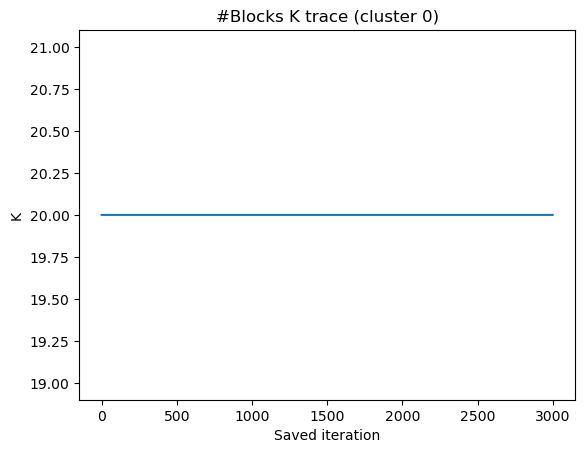

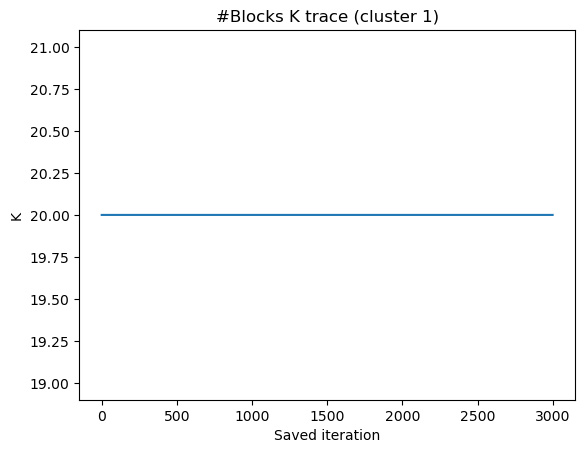

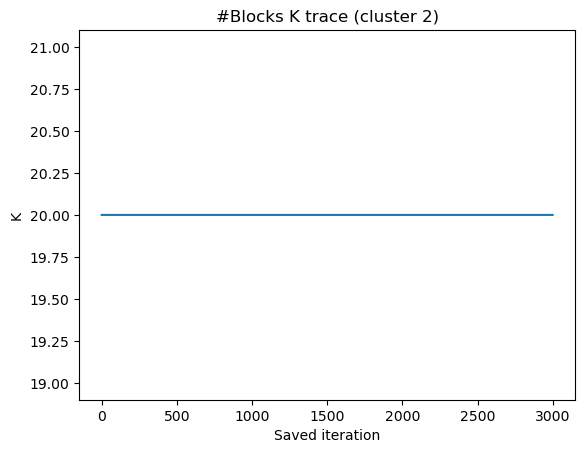

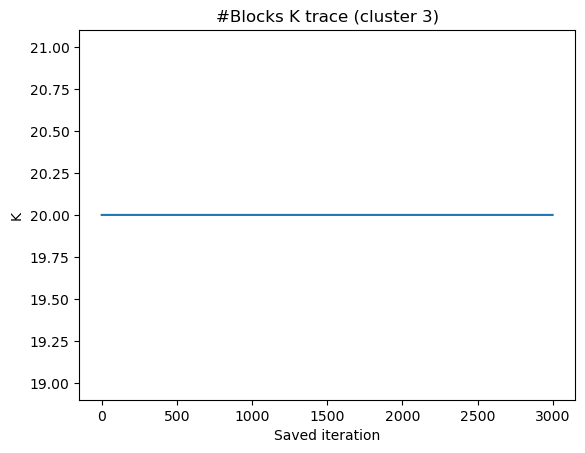

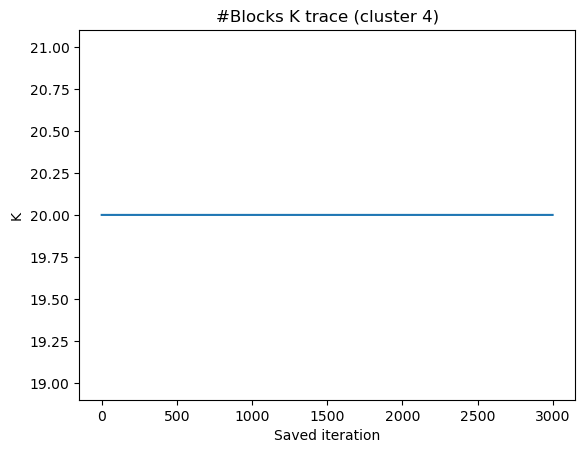

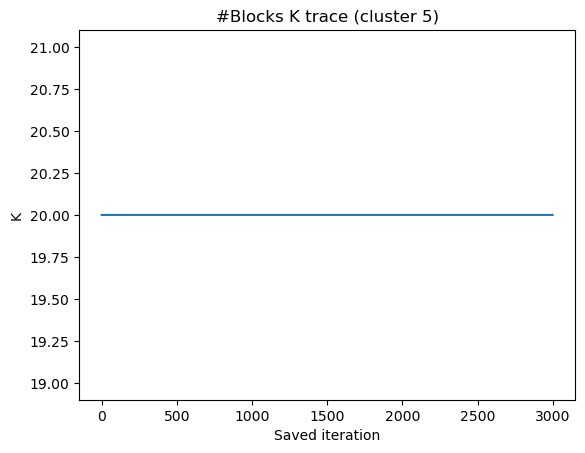

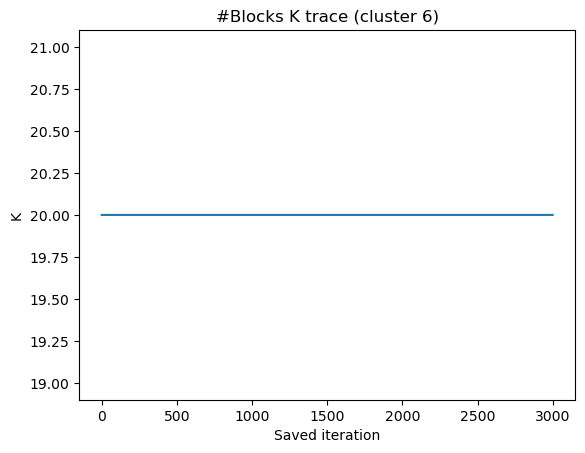

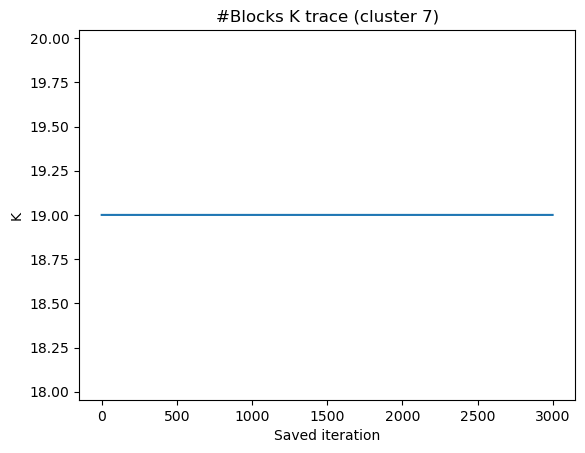

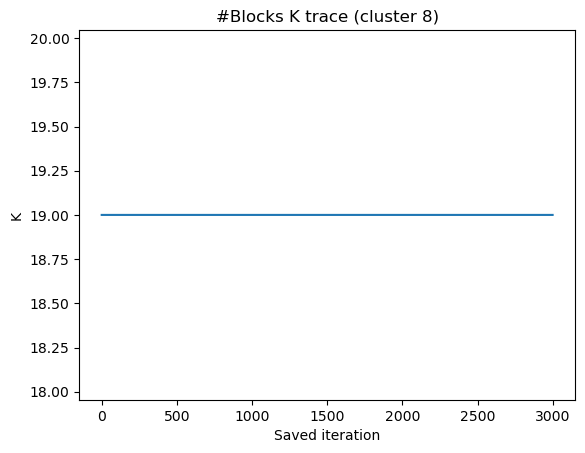

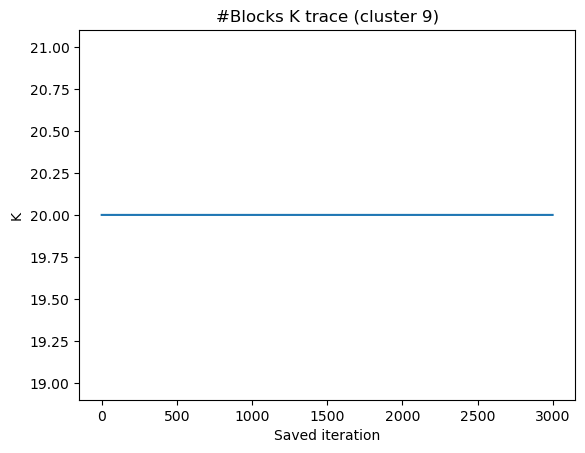

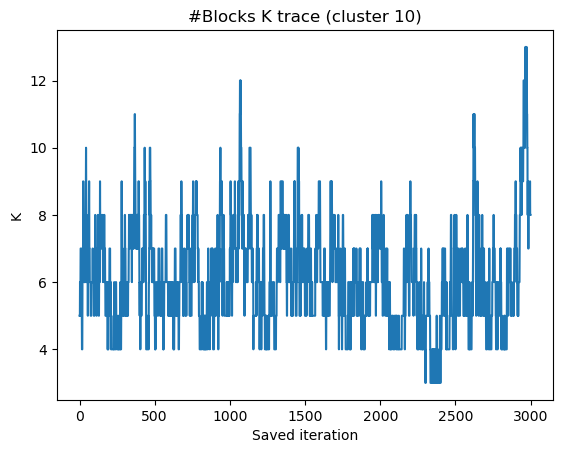

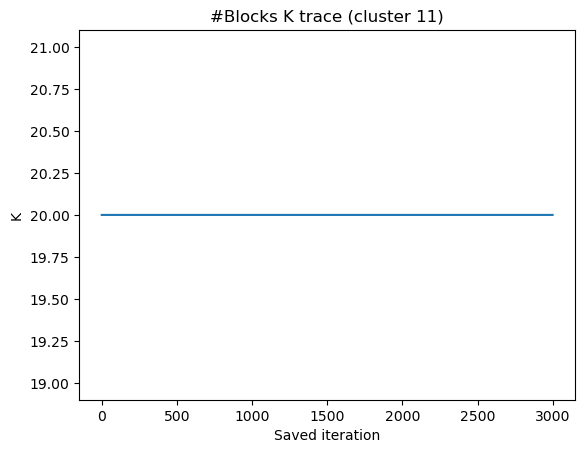

In [83]:
model.plot_trace_K()

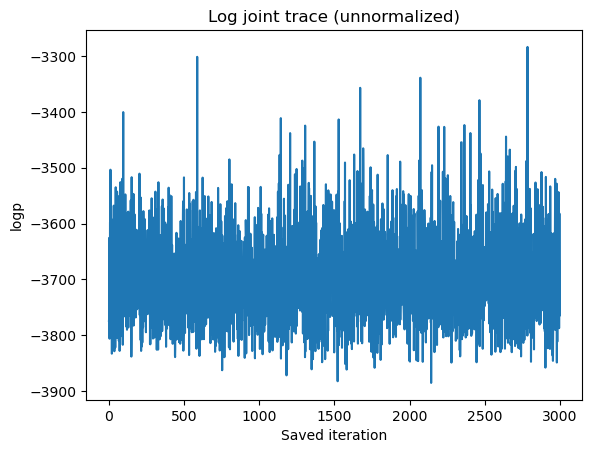

In [84]:
model.plot_trace_logp()

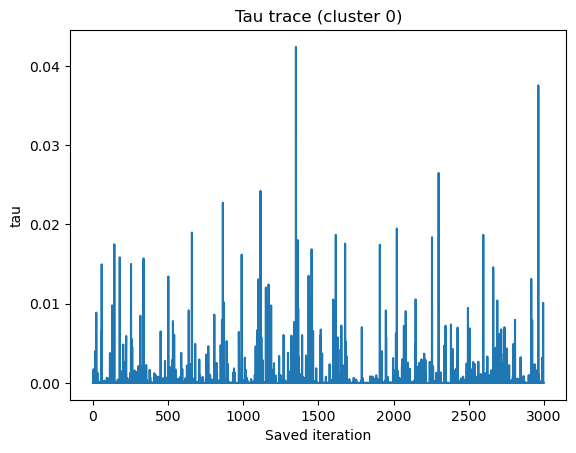

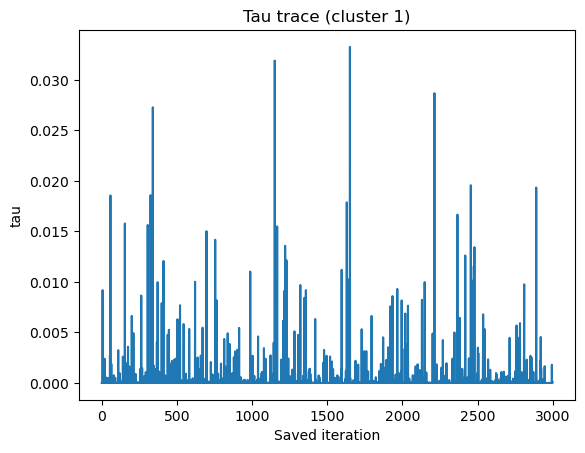

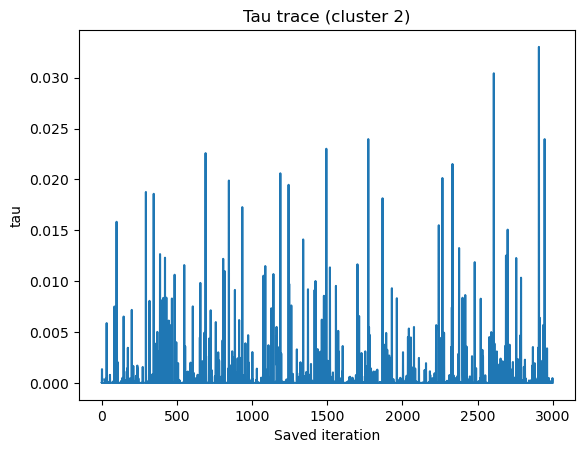

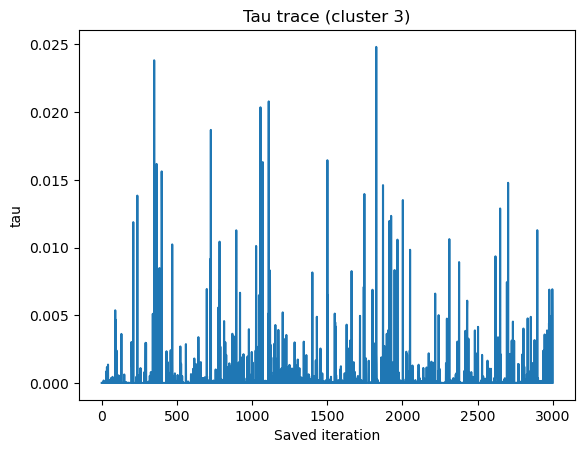

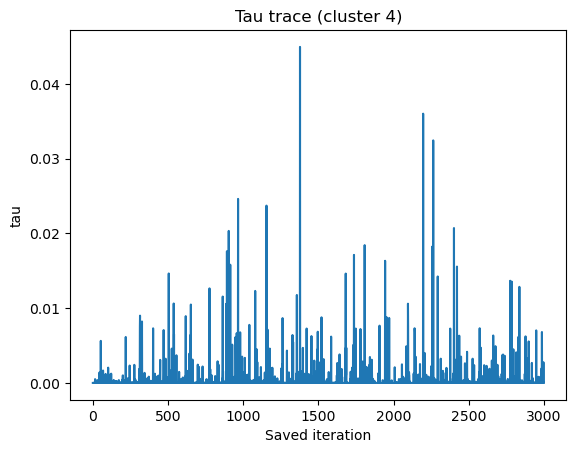

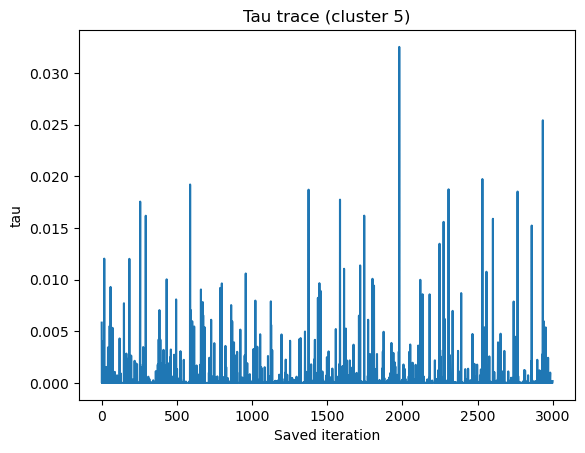

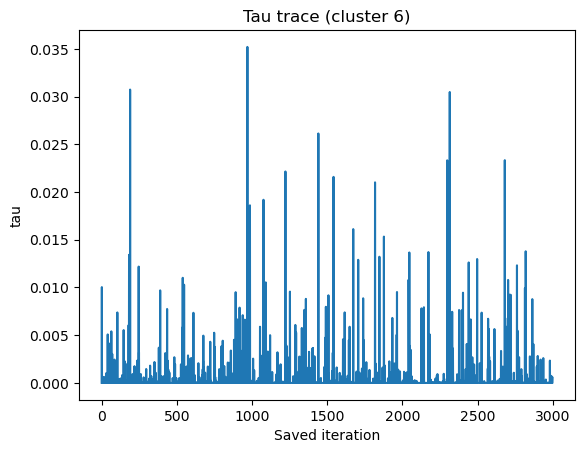

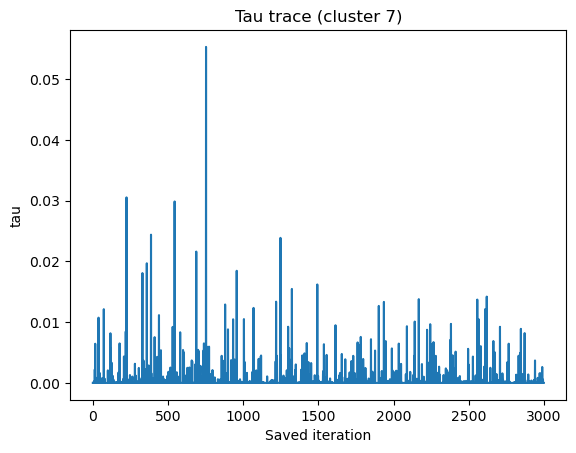

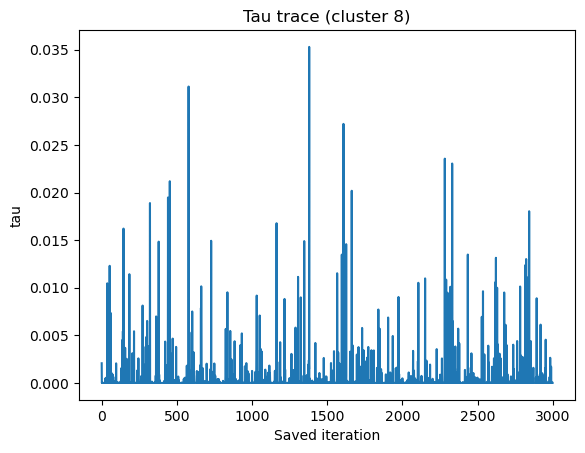

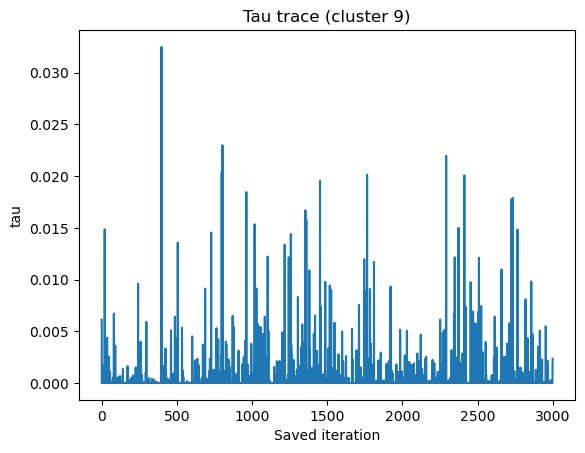

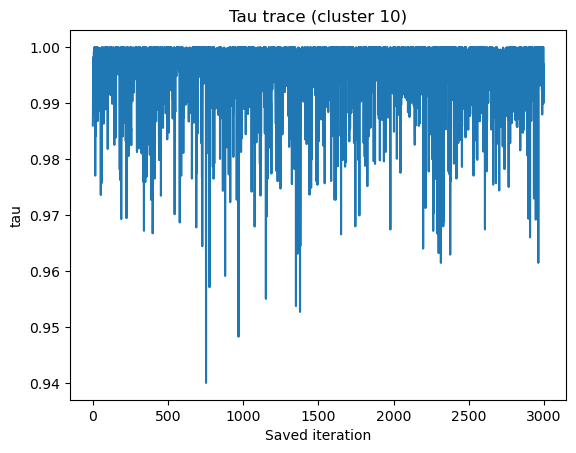

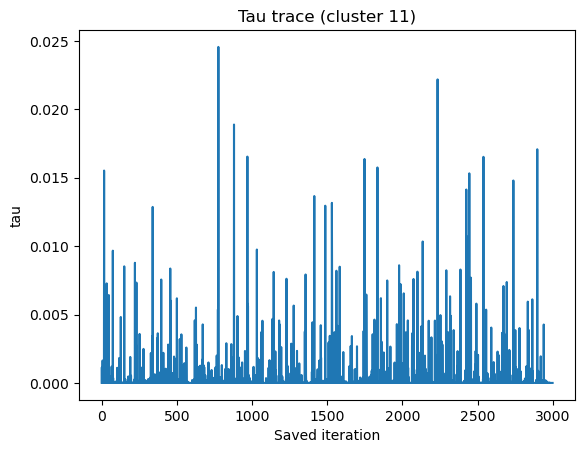

In [85]:
model.plot_trace_tau()

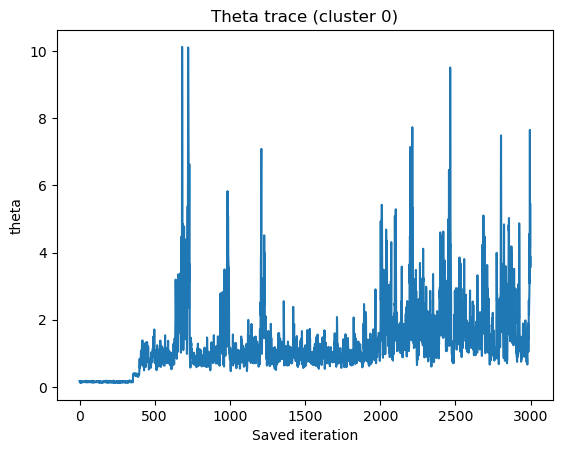

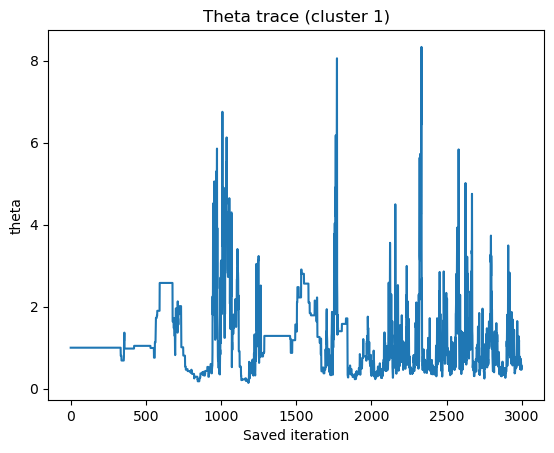

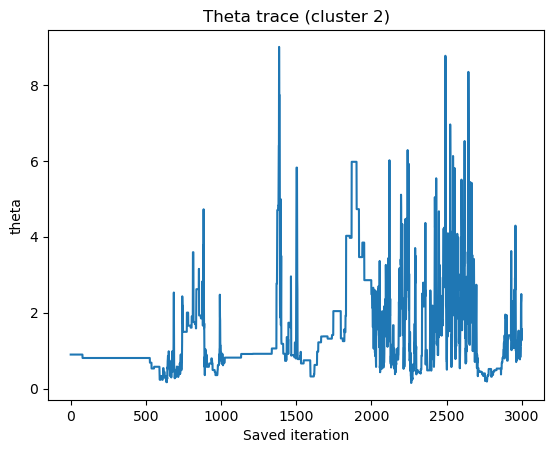

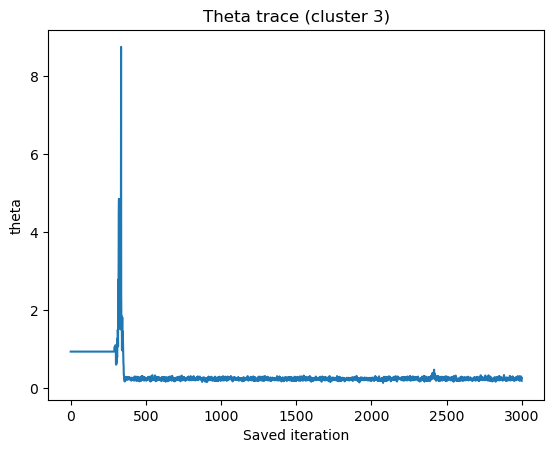

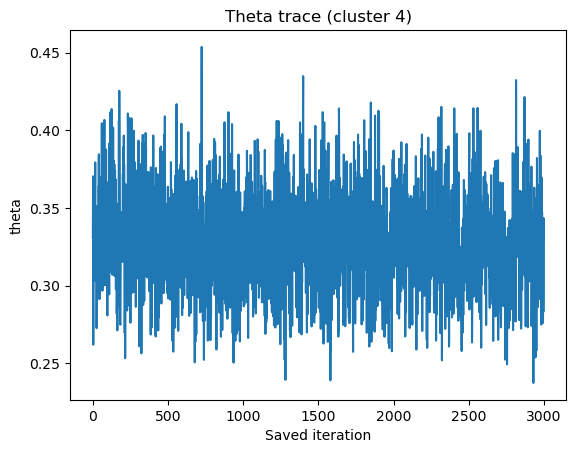

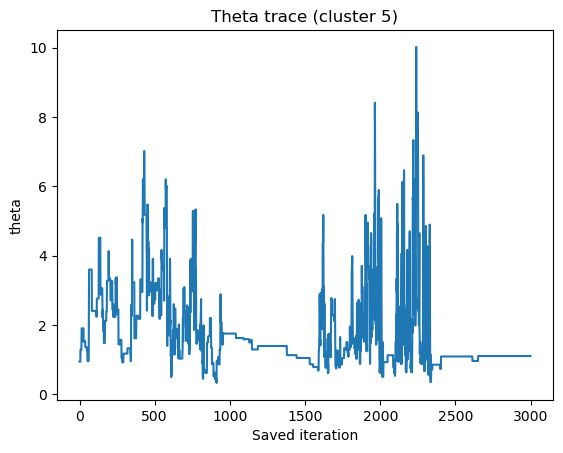

In [24]:
model.plot_trace_theta()

**Note:** the method `model.estimate_map` now accepts an optional `samples` argument.  
You can pass the object returned by `run_mcmc` (as shown above) or omit it entirely –
the function will fall back to using `model.samples` stored on the model.


In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

cm = confusion_matrix(y_true, y_pred)

# Hungarian algorithm to maximize matches
row_ind, col_ind = linear_sum_assignment(-cm)

# Create mapping: predicted → true
mapping = dict(zip(col_ind, row_ind))

# Remap predicted labels
y_pred_aligned = np.array([mapping[p] for p in y_pred])


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred_aligned, average='macro')
recall    = recall_score(y_true, y_pred_aligned, average='macro')
f1        = f1_score(y_true, y_pred_aligned, average='macro')

print(precision, recall, f1)


0.8214285714285715 0.811475869809203 0.8139166844084876


In [4]:
model.acceptance_statistics()

{'note': 'Acceptance statistics. Prefer exact tracking (theta_accepts/block_accepts) when available.',
 'theta': {'per_cluster': [{'cluster': 0,
    'n_accepts': 3,
    'acceptance_rate': 0.0004},
   {'cluster': 1, 'n_accepts': 3700, 'acceptance_rate': 0.49333333333333335},
   {'cluster': 2, 'n_accepts': 3592, 'acceptance_rate': 0.4789333333333333}],
  'overall_mean_acceptance': 0.32422222222222224,
  'n_iterations': 7500},
 'blocks': {'per_cluster': [{'cluster': 0,
    'n_accepts': 3,
    'acceptance_rate': 0.0004},
   {'cluster': 1, 'n_accepts': 2534, 'acceptance_rate': 0.33786666666666665},
   {'cluster': 2, 'n_accepts': 2008, 'acceptance_rate': 0.2677333333333333}],
  'overall_mean_acceptance': 0.20199999999999999,
  'n_iterations': 7500},
 'logp_improvement': {'n_iterations': 7499,
  'n_improvements': 3735,
  'improvement_rate': 0.4980664088545139}}

### Notes on block acceptance
The block-acceptance statistics returned by `model.acceptance_statistics()` or
`AcceptanceProbabilities.acceptance_probabilities` include all kinds of
block moves (split/merge, transfer, ordering, Gibbs) **and** the new
`p_py` PY‑prior MH proposals.  When you set ``p_py>0`` you should see the
corresponding proposal/accept counts reflected in the ``block_proposals``
and ``block_accept_counts`` fields of the returned dictionary.